# A mass-balance model for coexisting supramolecular copolymers

# Contents 

[Libraries](#Libraries)

[Custom Functions](#Custom-Functions)

[Speciation Plot](#Speciation-Plot) ||  [CD Plot](#CD-Plot)

[Fig S22](#Fig-S22) || [Fig S23](#Fig-S23)


[Theory](#Theory)        ||     [Mixed-P,M-helices](#Mixed-P,M-helices)  || [(AAR) Copolymer](#(AAR)-Copolymer) ||  [Homopolymer (R)](#Homopolymer-(R)) || [Physical Solutions](#Physical-solutions)


[Appendix](#Appendix)



[Contents](#Contents)
# Libraries


In [2]:
%pylab inline
import matplotlib.pyplot as plt
import numpy as np
import array as arr
import matplotlib.colors as colors
import scipy.linalg as la
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import string
from scipy.optimize import fsolve
#%from scipy import optimize

Alph=string.ascii_uppercase
alph=string.ascii_lowercase

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


[Contents](#Contents)
# Custom Functions 

In [10]:
def speciation_plot(fraclist,P1Plist,P1Mlist,P2list,P3list,ctotgoal):

    plt.plot(fraclist, 1000*np.array(P1Plist), 'bo',label = r'$m^P$')
    plt.plot(fraclist, 1000*np.array(P1Mlist), 'ro',label = r'$m^M$')
    plt.plot(fraclist, 1000*np.array(P2list), 'ko',label = r'$m^{(A_2R)}$')
    plt.plot(fraclist, 1000*np.array(P3list), 'mo',label = r'$m^{(R)}$')
    
    plt.plot([0.1,0.1],[-0.00001,ctotgoal*1000], 'k--')
    plt.plot([0.33,0.33],[-0.00001,ctotgoal*1000], 'k--')
    
    plt.text(0.015,0.9*ctotgoal*1000,'I',size=22)
    plt.text(0.195,0.9*ctotgoal*1000,'II',size=22)
    plt.text(0.57,0.9*ctotgoal*1000,'III',size=22)
    plt.ylim(-0.00001,ctotgoal*1000)
    
    plt.xlabel('Fraction R ' + r'$([R]_{tot}/c_{tot})$', size =14)
    plt.ylabel('Abundance (mM)',size=14)
    
    plt.grid('true')
    plt.legend(fontsize=12, borderaxespad = 0.1, ncol = 2, columnspacing = 0.1, borderpad = 0.1, handletextpad = 0.1)


def eps_phase_fieldIII(x, c_target):
    return 1 - x - x**2 + x**3 - c_target * x**2

def F_phase_fieldII(x,K_1,K_2,Q_t):
    return x**3 -1/K_1*x**2 + K_2/(K_1* Q_t) 

def phase_abundance(a_m, r_m, pars):
    K_1, K_2, K_4, K_5, Q_2, Q_3, Q_t, q_2t, q_3t, sigma_p, sigma_t, sigma_m, sigma_r, K_r = pars
    g_p, g_m = K_1*a_m + K_2*r_m, K_4*r_m + K_5*a_m
    
    pi_1p_a, pi_1m_a = sigma_p * a_m * g_p*(2-g_p)/((1-g_p)**2) ,  sigma_m * a_m * g_m*(2-g_m)/((1-g_m)**2) 
    pi_1p_r, pi_1m_r = K_2/K_1 * sigma_p * r_m * g_p*(2-g_p)/((1-g_p)**2),  K_5/K_4 * sigma_m * r_m * g_m*(2-g_m)/((1-g_m)**2)
    pi_2_a  = sigma_t*(2 + 2*Q_2*r_m + 3*Q_2*Q_3*r_m*a_m - Q_2*Q_3*Q_t*r_m**2*a_m**3)*(a_m**2*r_m)/(1-Q_t*a_m**2*r_m)**2 
    pi_2_r  = sigma_t*(1 + 2*Q_2*r_m + 2*Q_2*Q_3*r_m*a_m - Q_2*Q_t*r_m**2*a_m**2 - Q_2*Q_3*Q_t*r_m**2*a_m**3)*(a_m**2*r_m)/(1-Q_t*a_m**2*r_m)**2
    pi_3 = sigma_r / K_r *(2-K_r*r_m)*(K_r*r_m)**2/(1-K_r*r_m)**2
    
    a_tot =  a_m  +  pi_1p_a  +  pi_1m_a +  q_2t*r_m*a_m +  pi_2_a
    r_tot =  r_m  +  pi_1p_r  +  pi_1m_r +  q_2t*r_m*a_m +  pi_2_r + pi_3

    return a_tot, r_tot, pi_1p_a, pi_1m_a, pi_1p_r, pi_1m_r, pi_2_a, pi_2_r, pi_3

def plot_speciation(frac_list, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal):
    
    plt.plot(frac_list, 1000*np.array(pi_1p_list), 'bo',label = r'$m^P$')
    plt.plot(frac_list, 1000*np.array(pi_1m_list), 'ro',label = r'$m^M$')
    plt.plot(frac_list, 1000*np.array(pi_2_list), 'ko',label = r'$m^{(A_2R)}$')
    plt.plot(frac_list, 1000*np.array(pi_3_list), 'mo',label = r'$m^{(R)}$')
    
    plt.plot([0.1,0.1],[-0.00001, 1000* c_tot_goal], 'k--')
    plt.plot([0.33,0.33],[-0.00001, 1000* c_tot_goal], 'k--')
    
    plt.text(0.015, 0.9*1000* c_tot_goal,'I',size=22)
    plt.text(0.195, .9*1000* c_tot_goal,'II',size=22)
    plt.text(0.65, .9*1000* c_tot_goal,'III',size=22)
    plt.xlim(-0.02, 1.02)
    
    plt.ylim(-0.00001, 1000* c_tot_goal)
    
    plt.xlabel('fraction R ' + r'$([R]_{tot}/c_{tot})$')
    plt.ylabel('Abundance (mM)',size=14)
    
    plt.grid('true')
    plt.legend(fontsize=12)
    
def FigS22(aal, rrl, frl,K_1,K_2,Q_t):
    a_list, r_list, frac_list = aal, rrl, frl
    a_root = fsolve(F_phase_fieldII, [-1,0,1], args=(K_1,K_2,Q_t))
    r_root = 1/(Q_t*a_root**2)
    pII = a_root[2] #  2.65684651e-06   
    
    plt.plot([0,0.33],[1/K_2,1/K_2],'k--')
    plt.text(0.35,1/K_2,r'$1/K_2$')
    plt.plot([0.0,0.1],[1/K_1,1/K_1], 'k--')
    plt.text(0.12,1/K_1,r'$1/K_1$')
    
    plt.plot([0.33,1.0],[1/K_r,1/K_r], 'k--')
    plt.text(1.02,1/K_r,r'$1/Kr$')
    
    plt.plot([0.33,1.0],[(K_r/Q_t)**0.5,(K_r/Q_t)**0.5], 'k--')
    plt.text(1.01,(K_r/Q_t)**0.5,r'$\sqrt{K_r/Q_T}$')  #r'$(\frac{K_r}{Q_T})^{1/2}$')
    
    
    plt.plot([0.1,0.33],[pII, pII], 'k--')
    plt.text(0.35,pII,r'$[A]^{\text{II}}$')
    
    plt.plot([0.1,0.33],[1/(Q_t*pII**2), 1/(Q_t*pII**2)], 'k--')
    
    plt.text(0.35,1/(Q_t*pII**2),r'$1/(Q_T ([A]^{\text{II}})^2)$')
    
    plt.plot(frac_list,a_list,'ro',label=r'$[A]$')
    plt.plot(frac_list,r_list,'bs',label=r'$[R]$',markersize=5)
    
    plt.plot(frac_list,(np.array(a_list)**(2/3)*np.array(r_list)**(1/3)),'g>',label=r'$[A]^{2/3}[R]^{1/3}$',markersize=4) 
    plt.plot(frac_list,(K_1/K_2)*np.array(a_list) + np.array(r_list),'m^',label = r'$\frac{K_2}{K_1} [A] + [R]$',markersize=4) 
    
    plt.plot([0.1,1],[Q_t**(-1/3),Q_t**(-1/3)],'k--') 
    plt.text(1.02,Q_t**(-1/3),r'$1/Q_T^{1/3}$')
    
    plt.plot([0.1,0.1],[-0.0000,4*10**-6], 'k-')
    plt.plot([0.33,0.33],[-0.0000,4*10**-6], 'k-')
    
    plt.text(0.04,3.75*10**-6,r'$\text{I}$',size=16)
    plt.text(0.20,3.75*10**-6,r'$\text{II}$',size=16)
    plt.text(0.64,3.75*10**-6,r'$\text{III}$',size=16)
    
    
    plt.grid('true')
    plt.xlabel(r'$[R]_{tot}/c_{tot}$', size = 12)
    plt.xticks(size=12)
    plt.yticks(size=12)
    
    plt.ylabel('Abundance (M)',size = 12)
    
    plt.xlim(-0.02,1.15)
    plt.ylim(0.0,4*10**-6)
    
    plt.legend(ncol=1,fontsize=10)

def speciation_calc(ail, ril, pars, dev0, tol0, c_tot_goal):
    dev, tol = dev0, tol0
    a_init_list, r_init_list = ail, ril
    a_list, r_list, c_tot_list, frac_list, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list = [], [], [], [], [], [], [], []
     
    for zz in range(len(a_init_list)):
        for k in range(len(a_init_list[zz])):
            for qq in range(2000):
                ##### Initialize variables
                a_m, r_m = a_init_list[zz][k]*(1-dev), r_init_list[zz][k]*(1-dev)  # [A], [R] , initial guess                                            
                a_tot, r_tot, pi_1p_a, pi_1m_a, pi_1p_r, pi_1m_r, pi_2_a, pi_2_r, pi_3 = phase_abundance(a_m, r_m, pars)
        
                if (a_tot + r_tot) > c_tot_goal:
                    dev = dev*(1 + 10**(-1-(qq)/25))
                else:
                    dev = dev*(1 - 10**(-1-(qq)/25))
                    
            if ((((a_tot + r_tot) - c_tot_goal)**2)**0.5 < c_tot_goal*tol):
                a_list.append(a_m), r_list.append(r_m), pi_1p_list.append(pi_1p_a + pi_1p_r) 
                pi_1m_list.append(pi_1m_a + pi_1m_r), pi_2_list.append(pi_2_a + pi_2_r), pi_3_list.append(pi_3)
                c_tot_list.append(a_tot + r_tot), frac_list.append(r_tot / (a_tot + r_tot))
                
            else:
                print('jammer',zz,k,a_tot,dev)
                if dev < 10**(-10):
                    dev = dev0

    return a_list, r_list, frac_list, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_list


[Contents](#Contents)
# Speciation Plot

[Contents](#Contents)
### 200 $\mu M$

### Parameters 

In [11]:
RT = 8.3145*313
dHmm = - 0.34*RT #2.3*RT
dHnuc = -3*RT     #2740 #-27400
K_2 = 10**(5.6)
K_1,K_5 = K_2*exp(dHmm/(RT)) ,K_2*exp(dHmm/(RT))
K_4 = K_5*exp(dHmm/(RT))
sigma_m, sigma_p = exp(dHnuc/RT), exp(dHnuc/RT)
Q_t = 10**(17.6)

Q_1, Q_2, Q_3, q_2t, q_3t = Q_t**(1/3), Q_t**(1/3), Q_t**(1/3), 10**3, 10**3
sigma_t = q_2t * q_3t
c_tot_goal_02 = 0.00020
chi = 9
K_r, sigma_r = 10**(6), 10**(-3)

pars = K_1, K_2, K_4, K_5, Q_2, Q_3, Q_t, q_2t, q_3t, sigma_p, sigma_t, sigma_m, sigma_r, K_r 

K_1alt, K_2alt, Q_talt = [K_1, K_2, Q_t].copy()

### Initial guess - approximate solutions

Our system of equations admits several solutions, but only one corresponds to a physical solution. 
An added difficulty is that when two phases coexist, the underlying values of monomer concentrations are close to fixed, and thus we need to solve our system of equations for very small variations.


In [12]:
e1, e2 = np.logspace(-4,-1,30), np.logspace(-1,-0.0000001,30)
e3 = np.concatenate((e1,e2))

gg, ff, jj = 1.0, 0.96, 0.99
a_ref, r_ref = chi/(K_1*chi + K_2), 1/(K_1*chi + K_2)

a_list_pfI_02 = 1/K_1 + (ff * a_ref  - 1/K_1) * e3 
r_list_pfI_02 = 10**(-12) + ff * r_ref * e3

a_list_pfII_02 = a_ref + (1.5/Q_t**(1/3) - a_ref)*e3
r_list_pfII_02 = 1/(Q_t * a_list_pfII_02**2)

ctarget = c_tot_goal_02 * K_r/sigma_r
root = fsolve(eps_phase_fieldIII, [-1,0,1], args = (ctarget,))

r_list_pfIII_02 = jj/K_r + ((1-root[1])/K_r - jj/K_r)*e3
a_list_pfIII_02 = 1/(Q_t*r_list_pfIII_02)**(1/2)

r_terminal = (1-root[1])/K_r
a_fin = 1/(Q_t*(1-root[1])/K_r)**(1/2)
r_fin = r_list_pfIII_02[-1] 

r_list_pfIV_02 = r_fin + (r_terminal -  r_fin)*e3
a_list_pfIV_02 = a_fin - a_fin*e3

### Calculate & Display

jammer 0 0 0.0015110203243778998 0.015142813434355685
jammer 0 56 0.00017052763801077487 0.000832566361193117
jammer 0 57 0.0001490296162559963 0.00025899830515386927
jammer 0 58 0.00012681397141635134 8.057030069824928e-05
jammer 0 59 0.00010721141586795088 2.5064153801121293e-05
jammer 1 0 0.00038183822480767455 7.590836098007524e-05
jammer 1 1 0.000237678506892362 0.0002298932296858008
jammer 1 2 0.00021561218029821243 0.0006962460573907112
jammer 1 3 0.0001958860729328856 0.0021086248302946437


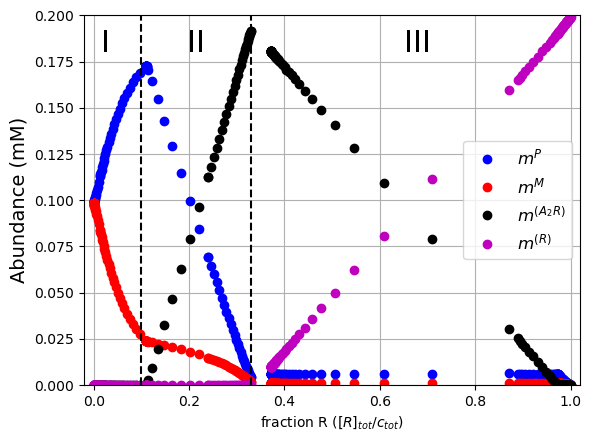

In [13]:
########### Solve ###########
a_list_02, r_list_02, c_tot_list, frac_list_02 = [], [], [], []
pi_1p_list, pi_1m_list, pi_2_list, pi_3_list = [], [], [], []
            
dev0, tol0 = 0.005, 0.001
a_init_list_02, r_init_list_02 = [a_list_pfI_02, a_list_pfII_02, a_list_pfIII_02, a_list_pfIV_02], [r_list_pfI_02, r_list_pfII_02, r_list_pfIII_02, r_list_pfIV_02] 
#a_init_list, r_init_list = a_list_02, r_list_02
a_list_02, r_list_02, frac_list_02, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_list = speciation_calc(a_init_list_02, r_init_list_02, pars, dev0, tol0, c_tot_goal_02)

plot_speciation(frac_list_02, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal_02)

[Contents](#Contents)
### 50 $\mu M$

### Parameters

In [37]:
c_tot_goal_005 = 0.00005
pars = K_1, K_2, K_4, K_5, Q_2, Q_3, Q_t, q_2t, q_3t, sigma_p, sigma_t, sigma_m, sigma_r, K_r 

### Initial guess - approximate solutions

In [38]:
e1, e2 = np.logspace(-4,-1,30), np.logspace(-1,-0.0000001,30)
e3 = np.concatenate((e1,e2))

gg, ff, jj = 1.0, 0.936, 0.95
a_ref, r_ref = chi/(K_1*chi + K_2), 1/(K_1*chi + K_2)

a_list_pfI_005 = 1/K_1 + (ff * a_ref  - 1/K_1) * e3 
r_list_pfI_005 = 10**(-12) + ff * r_ref * e3

a_list_pfII_005 = ff*a_ref + (1.5/Q_t**(1/3) - ff*a_ref)*e3
r_list_pfII_005 = 1/(Q_t * a_list_pfII_005**2)

ctarget = c_tot_goal_005 * K_r/sigma_r
root = fsolve(eps_phase_fieldIII, [-1,0,1], args = (ctarget,))

r_list_pfIII_005 = jj/K_r + ((1-root[1])/K_r - jj/K_r)*e3
a_list_pfIII_005 = 1/(Q_t*r_list_pfIII_005)**(1/2)

r_terminal = (1-root[1])/K_r
a_fin = 1/(Q_t*(1-root[1])/K_r)**(1/2)
r_fin = r_list_pfIII_005[-1] 

r_list_pfIV_005 = r_fin + (r_terminal -  r_fin)*e3
a_list_pfIV_005 = a_fin - a_fin*e3



### Calculate & Display

jammer 0 0 0.000758567294850409 0.015142813434355685
jammer 0 1 8.251180790503405e-05 0.0458609597415405
jammer 0 55 4.3139947381247976e-05 0.0013120731717090157
jammer 0 56 3.804889282245604e-05 0.000408165334981235
jammer 0 57 3.2455492622990116e-05 0.00012697381843677504
jammer 0 58 2.7636504567742576e-05 3.9499558602046145e-05
jammer 0 59 2.3492793317427946e-05 1.2287691659311384e-05
jammer 1 0 0.0003542162591683826 3.72140444671681e-05
jammer 1 1 5.345954503704485e-05 0.00011270506650082858


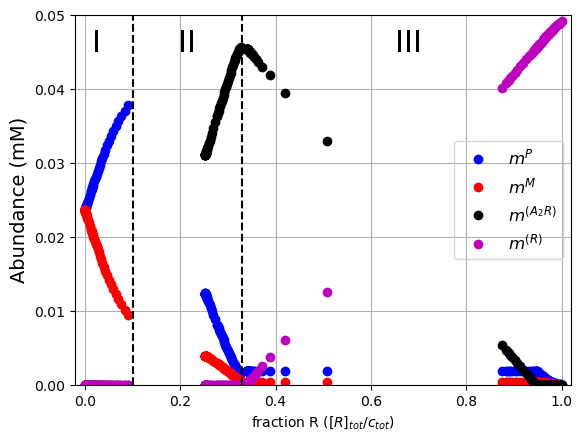

In [39]:
########### Solve ###########
a_list_005, r_list_005, c_tot_list, frac_list_005 = [], [], [], []
pi_1p_list, pi_1m_list, pi_2_list, pi_3_list = [], [], [], []
            
dev0, tol0 = 0.005, 0.001
a_init_list_005, r_init_list_005 = [a_list_pfI_005, a_list_pfII_005, a_list_pfIII_005, a_list_pfIV_005], [r_list_pfI_005, r_list_pfII_005, r_list_pfIII_005, r_list_pfIV_005] 
a_list_005, r_list_005, frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_list = speciation_calc(a_init_list_005, r_init_list_005, pars, dev0, tol0, c_tot_goal_005)

plot_speciation(frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal_005)

In [40]:
5.7+0.45

6.15

# Another set of parameters (used for plots)

In [41]:
RT = 8.3145*313
dHmm = - 0.38*RT #2.3*RT
dHnuc = -3.5*RT     #2740 #-27400
K_2 = 10**(5.7)
K_1,K_5 = K_2*exp(dHmm/(RT)) ,K_2*exp(dHmm/(RT))
K_4 = K_5*exp(dHmm/(RT))
sigma_m, sigma_p = exp(dHnuc/RT), exp(dHnuc/RT)
Q_t = K_2**3*10**(0.8)

Q_1, Q_2, Q_3, q_2t, q_3t = Q_t**(1/3), Q_t**(1/3), Q_t**(1/3), 10**3, 10**3
sigma_t = q_2t * q_3t
c_tot_goal_005 = 0.000050
chi = 9
K_r, sigma_r = K_2*10**(0.45), 10**(-3)

pars = K_1, K_2, K_4, K_5, Q_2, Q_3, Q_t, q_2t, q_3t, sigma_p, sigma_t, sigma_m, sigma_r, K_r 

In [42]:
e1, e2 = np.logspace(-4,-1,30), np.logspace(-1,-0.0000001,100)
e3 = np.concatenate((e1,e2))

gg, ff, jj = 1.0, 0.935, 0.97
a_ref, r_ref = chi/(K_1*chi + K_2), 1/(K_1*chi + K_2)

a_list_pfI_005 = 1/K_1 + (ff * a_ref  - 1/K_1) * e3 
r_list_pfI_005 = 10**(-12) + ff * r_ref * e3

a_list_pfII_005 = a_ref + (1.5/Q_t**(1/3) - a_ref)*e3
r_list_pfII_005 = 1/(Q_t * a_list_pfII_005**2)

ctarget = c_tot_goal_005 * K_r/sigma_r
root = fsolve(eps_phase_fieldIII, [-1,0,1], args = (ctarget,))

r_list_pfIII_005 = jj/K_r + ((1-root[1])/K_r - jj/K_r)*e3

#r_list_pfIII_005 = pf3_ref/K_r + (1.001/K_r - pf3_ref/K_r)*e3
a_list_pfIII_005 = 1/(Q_t*r_list_pfIII_005)**(1/2)

r_terminal = (1-root[1])/K_r
a_fin = 1/(Q_t*(1-root[1])/K_r)**(1/2)
r_fin = r_list_pfIII_005[-1] 

r_list_pfIV_005 = r_fin + (r_terminal -  r_fin)*e3
a_list_pfIV_005 = a_fin - a_fin*e3

jammer 0 0 0.019034999819090667 0.0030285626868711384
jammer 0 1 0.0020724755722844345 0.009172191948308112
jammer 0 2 0.00022442673354729507 0.02777855829146583
jammer 0 115 4.422305479860195e-05 0.00031115885789087376
jammer 0 116 4.2480399947967404e-05 9.679662857367952e-05
jammer 0 117 4.059078372155074e-05 3.011190928884586e-05
jammer 0 118 3.8730319395892896e-05 9.367341552908525e-06
jammer 0 119 3.756049009196857e-05 2.914032681459693e-06
jammer 0 120 3.5220301960088944e-05 9.065097520628544e-07
jammer 0 121 3.355436801374969e-05 2.820009314972482e-07
jammer 0 122 3.1984077056583164e-05 8.77260561007201e-08
jammer 0 123 3.0489552381148935e-05 2.729019680228174e-08
jammer 0 124 2.9065800310242797e-05 8.489551161996839e-09
jammer 0 125 2.77091916328457e-05 2.6409658916837124e-09
jammer 0 126 2.6416481205358525e-05 8.215629669868455e-10
jammer 0 127 2.5184635361619587e-05 2.555753222143706e-10
jammer 0 128 2.4010782566621844e-05 7.950546452275191e-11
jammer 0 129 2.2720402519790685

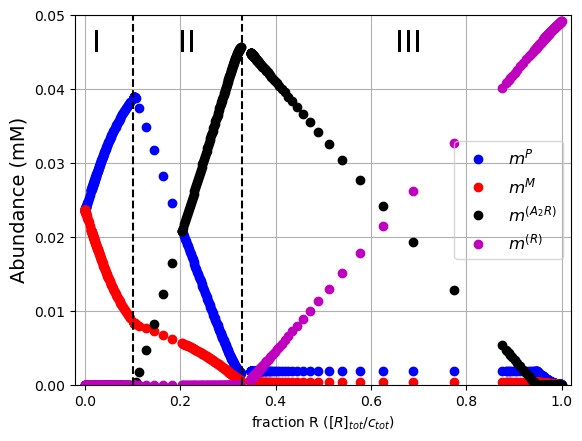

In [43]:
########### Solve ###########
a_list_005, r_list_005, c_tot_list, frac_list_005 = [], [], [], []
pi_1p_list, pi_1m_list, pi_2_list, pi_3_list = [], [], [], []
            
dev0, tol0 = 0.001, 0.001
a_init_list_005, r_init_list_005 = [a_list_pfI_005, a_list_pfII_005, a_list_pfIII_005, a_list_pfIV_005], [r_list_pfI_005, r_list_pfII_005, r_list_pfIII_005, r_list_pfIV_005] 
a_list_005, r_list_005, frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_list = speciation_calc(a_init_list_005, r_init_list_005, pars, dev0, tol0, c_tot_goal_005)

plot_speciation(frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal_005)

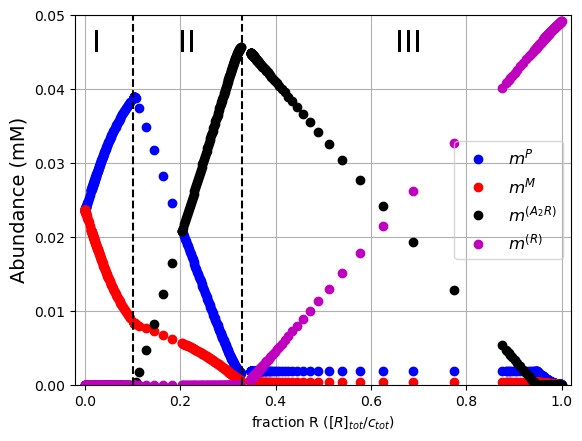

In [44]:
plot_speciation(frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal_005)

In [45]:
def plot_speciation_pastel(frac_list, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal):
    
    plt.plot(frac_list, 1000*np.array(pi_1p_list), '+',color='dodgerblue', label = r'$m^P$')
    plt.plot(frac_list, 1000*np.array(pi_1m_list),  'x',color='tomato' , label = r'$m^M$')
    plt.plot(frac_list, 1000*np.array(pi_2_list), '^',color='orange', label = r'$m^{(A_2R)}$')
    plt.plot(frac_list, 1000*np.array(pi_3_list),  'o',color='lightgreen', label = r'$m^{(R)}$')
    
    plt.plot([0.1,0.1],[-0.00001, 1000* c_tot_goal], 'k--')
    plt.plot([0.33,0.33],[-0.00001, 1000* c_tot_goal], 'k--')
    
    plt.text(0.015, 0.9*1000* c_tot_goal,'I',size=22)
    plt.text(0.195, .9*1000* c_tot_goal,'II',size=22)
    plt.text(0.65, .9*1000* c_tot_goal,'III',size=22)
    plt.xlim(-0.02, 1.02)
    
    plt.ylim(-0.00001, 1000* c_tot_goal)
    
    plt.xlabel('fraction R ' + r'$([\text{R}]_{tot}/c_{tot})$',size = 14)
    plt.ylabel('Abundance (mM)',size=14)
    
    #plt.grid('true')
    plt.legend(fontsize=12)
    

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


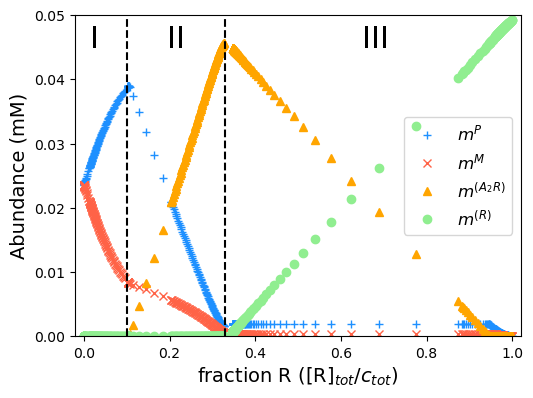

In [46]:
plt.figure(figsize=(14.6/2.54, 10.6/2.54))
plot_speciation_pastel(frac_list_005, pi_1p_list, pi_1m_list, pi_2_list, pi_3_list, c_tot_goal_005)


title = 'spec_diag_new_nnb'

plt.savefig(title + '.eps',bbox_inches='tight')
plt.savefig(title + '.pdf',bbox_inches='tight')
plt.savefig(title + '.tiff',bbox_inches='tight')


[Contents](#Contents)
# CD Plot 

### CD Data 

In [28]:
RL = [2,5,10,15,20,30,33,40,50,60,80,100]
CDR = [-61.66827,-133.74873,-197.67367,-135.97027,-65.56747,12.64603,94.9991,74.0581,37.10693,19.00257,-9.50283,-46.21847]
err_R = [39.30774,33.82167,30.60649,52.66947,39.65203,35.00881,10.76117,27.65008,18.73704,3.34504,9.08514,18.5841]
     
SL = [-2,-5,-8,-10,-15,-20,-30,-33,-40,-50,-60,-80]
CDL = [57.03627,87.1972,119.46467,249.99433,130.676,89.93343,-25.3015,-19.63683,-20.76287,-17.93677,-4.15753,10.15684]
err_S = [19.54873,16.81295,24.82661,45.08042,26.08361,16.2093,3.115,4.91569,8.95256,4.25472,12.21384,5.90538]

RSL = [-100,-40,-10,10,40,100]
CDSL = [48.0942,17.3049,3.60374,-2.64705,-10.3263,-44.0823]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


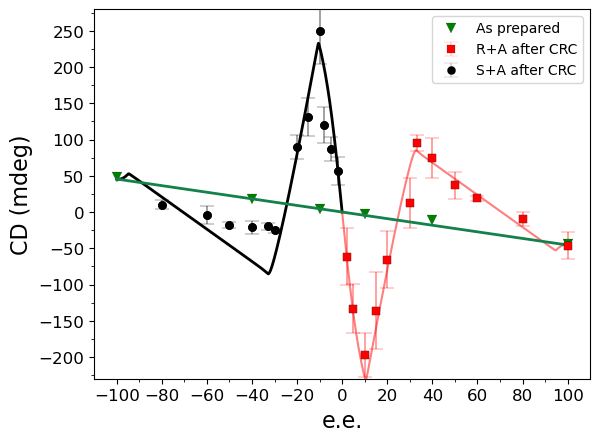

In [36]:
#plt.rcParams['axes.facecolor'] = '0.99, 0.99, 0.97' # '1.0, 1.0, 0.87, 0.2'#'lightyellow'# 'lightgoldenrodyellow' #'beige'
plt.rcParams['axes.facecolor'] = 'none' #'0.99, 0.99, 0.97' # '1.0, 1.0, 0.87, 0.2'#'lightyellow'# 'lightgoldenrodyellow' #'beige'

plt.rcParams['figure.facecolor'] = 'none'
#plt.figure(figsize=(8.6/2.54, 8.6/2.54))

alph1 = (np.array(pi_1p_list)-np.array(pi_1m_list))*(-1900000)*4
alph2 = (np.array(pi_2_list))*(510000)*4
alph3 = (np.array(pi_3_list))*(-230000)*4
frac_list = frac_list_005

xmin,xmax = -110,110
ymin,ymax = -230,280
#plt.plot([xmin,xmax],[0,0],'k-',linewidth=1)
#plt.plot([0,0],[ymin,ymax],'k-',linewidth=1)
plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)
#plt.plot(fraclist,alph1+alph2+alph3,'ro')

#plt.plot([-100*fraclist[-1],100*fraclist[-1]],[-(alph1+alph2+alph3)[-1],(alph1+alph2+alph3)[-1]],color=(0.08, 0.50, 0.29), linewidth = 2)


plt.plot(100*np.array(frac_list_005[:]), (alph1+alph2+alph3)[:],'-' ,color='red', markersize = 3,alpha=0.5)

plt.errorbar(RL, CDR, yerr=err_R, capsize=5, color = 'red', markersize=6, marker = 's', markeredgecolor='k', mew = 0.1, label = 'R+A after CRC', linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')
plt.errorbar(RL, CDR, yerr=err_R, capsize=5, color = 'red', markersize=6, marker = 's', markeredgecolor='k', mew = 0.1,  linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')
plt.errorbar(RL, CDR, yerr=err_R, capsize=5, color = 'red', markersize=6, marker = 's', markeredgecolor='k', mew = 0.1,  linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')

mfraca = (-1)*np.array(frac_list_005)

plt.plot(100*np.array(mfraca),(-alph1-alph2-alph3), color = 'black',linewidth = 2)

plt.errorbar(SL, CDL, yerr=err_S, capsize=5, color = 'black', markersize=6, marker = 'o', markeredgecolor='k', mew = 0.1, label = 'S+A after CRC', linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')
plt.errorbar(SL, CDL, yerr=err_S, capsize=5, color = 'black', markersize=6, marker = 'o', markeredgecolor='k', mew = 0.1,  linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')
plt.errorbar(SL, CDL, yerr=err_S, capsize=5, color = 'black', markersize=6, marker = 'o', markeredgecolor='k', mew = 0.1,  linewidth = 0.2,capthick=10,alpha=1, linestyle = 'none')


plt.plot(RSL,CDSL, color = 'green', markersize = 7, marker = 'v', markeredgecolor='k', mew = 0.1, linestyle = 'none', label= 'As prepared')
plt.plot([-100*frac_list[-1],100*frac_list[-1]],[-(alph1+alph2+alph3)[-1],(alph1+alph2+alph3)[-1]],color=(0.08, 0.50, 0.29), linewidth = 2)


plt.xlabel('e.e.', size = 16)
plt.ylabel('CD (mdeg)', size = 16)
plt.xticks([-100,-80,-60,-40,-20,0,20,40,60,80,100],size=12)
plt.xticks([-90,-70,-50,-30,-10,10,30,50,70,90],size=12,minor='True')
plt.legend()

plt.yticks([-200,-150,-100, -50, 0, 50, 100, 150, 200, 250], size=12)
plt.yticks([-225,-175,-125,-75,-25,25,75, 125, 175,225,275],size=12,minor='True')
#plt.ylim(-300,300)
#ax.set_facecolor('lightgrey')
title = 'CDfigPoints3d_new'
plt.savefig(title + '.eps',bbox_inches='tight')
plt.savefig(title + '.pdf',bbox_inches='tight')
plt.savefig(title + '.png',bbox_inches='tight', facecolor = 'white')

[Contents](#Contents)
# Fig S23

In [78]:
a_root = fsolve(F_phase_fieldII, [-1,0,1], args=(K_1,K_2,Q_t))
r_root = 1/(Q_t*a_root**2)
a_root,r_root

(array([-7.12155440e-07,  9.71795197e-07,  2.65684651e-06]),
 array([2.48227794e-06, 1.33306247e-06, 1.78347518e-07]))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


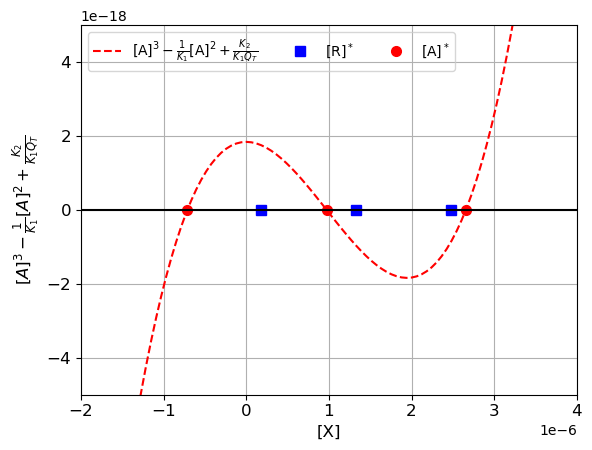

In [163]:
xx, yy = np.linspace(-2*10**(-6),4*10**(-6),100),  np.linspace(10**(-9),3.5*10**(-6),100)
plt.plot(xx,xx**3 -1/K_1*xx**2 + K_2/(K_1 * Q_t ),'r--',label=r'$[\text{A}]^3-\frac{1}{K_1}[\text{A}]^2 +\frac{K_2}{K_1 Q_T} $')

plt.plot(r_root,[0,0,0],'bs',markersize=7,label=r'$[\text{R}]^*$') # solutions for [R]
plt.plot(a_root,[0,0,0],'ro',markersize=7,label=r'$[\text{A}]^*$') # solutions for [A]

plt.plot([-3*10**(-6),5*10**(-6)],[0,0],'k')
plt.grid('true') 
plt.xlim(-2*10**(-6),4*10**(-6))
plt.ylim(-5*10**(-18),5*10**(-18))
plt.legend(ncol=3,fontsize=10)

plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel('[X]',size = 12)
plt.ylabel(r"$[A]^3-\frac{1}{K_1}[A]^2 +\frac{K_2}{K_1 Q_T} $",size = 12)
#
title = 'sol_eq_new_nnb'

plt.savefig(title + '.eps',bbox_inches='tight')
plt.savefig(title + '.pdf',bbox_inches='tight')
plt.savefig(title + '.tiff',bbox_inches='tight')


[Contents](#Contents)
# Fig S22

### 200 $\mu M$

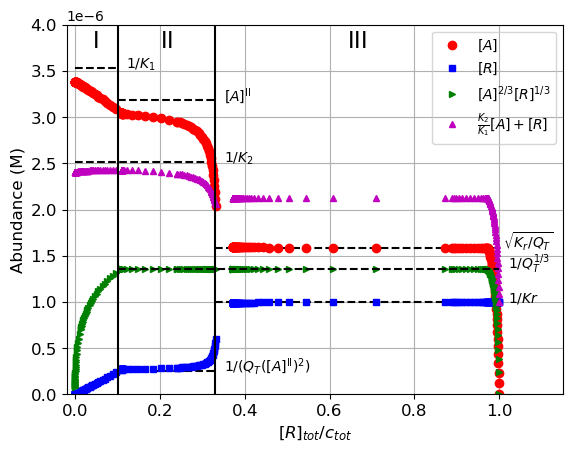

In [108]:
FigS22(a_list_02, r_list_02, frac_list_02, K_1alt, K_2alt, Q_talt)

### 50 $\mu M$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


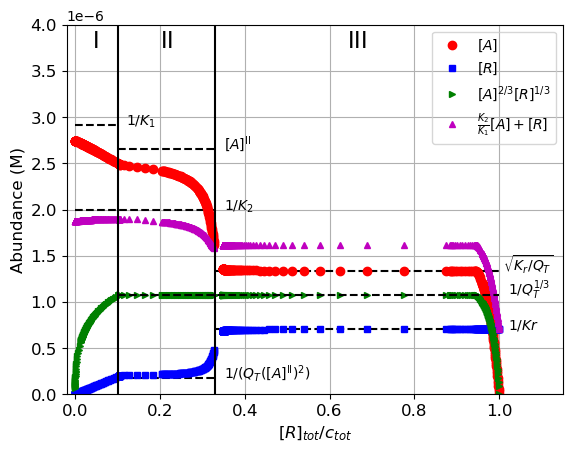

In [161]:
FigS22(a_list_005, r_list_005, frac_list_005,K_1,K_2,Q_t)
title = 'mon_ab_new_nnb'

plt.savefig(title + '.eps',bbox_inches='tight')
plt.savefig(title + '.pdf',bbox_inches='tight')
plt.savefig(title + '.tiff',bbox_inches='tight')


In [159]:
title = 'mon_ab_new_nnb'

plt.savefig(title + '.eps',bbox_inches='tight')
plt.savefig(title + '.pdf',bbox_inches='tight')
plt.savefig(title + '.tiff',bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

[Contents](#Contents)
# Theory

[Contents](#Contents)
### Mixed P,M helices

We follow [Eik12] for an elegant model that retains essential ingredients to capture amplification of chiroptical response.
The model considers two types of helices ($P$ resp. $M$) that can form, denoted by ($\text{X}$)

Reactions for the nucleation of the P-helix are

$\text{A} + \text{A} \underset{\kappa_1^-}{\overset{\kappa_1^+}{\leftrightarrows}} \text{AA}^{(P)}, \ \ \ \text{A} + \text{R} \underset{\kappa_2^-}{\overset{\kappa_2^+}{\leftrightarrows}} \text{AR}^{(P)}, \ \ \ \text{R} + \text{A} \underset{\kappa_2^-}{\overset{\kappa_2^+}{\leftrightarrows}} \text{RA}^{(P)}, \ \ \ \text{R} + \text{R} \underset{\kappa_3^-}{\overset{\kappa_3^+}{\leftrightarrows}} \text{RR}^{(P)}$ 

ibid for M-helix

$\text{A} + \text{A} \underset{\kappa_4^-}{\overset{\kappa_4^+}{\leftrightarrows}} \text{AA}^{(M)}, \ \ \ \text{A} + \text{R} \underset{\kappa_5^-}{\overset{\kappa_5^+}{\leftrightarrows}} \text{AR}^{(M)}, \ \ \ \text{R} + \text{A} \underset{\kappa_5^-}{\overset{\kappa_5^+}{\leftrightarrows}} \text{RA}^{(M)}, \ \ \ \text{R} + \text{R} \underset{\kappa_6^-}{\overset{\kappa_6^+}{\leftrightarrows}} \text{RR}^{(M)}$ 

and thereafter we can consider elongation, depending only on the helix type, i.e. sensitive to $k=0$ neighbors

$(\text{A}_{n}\text{R}_{m})^P + \text{A}\underset{\kappa_1^-}{\overset{k_1^+}{\leftrightarrows}}  (\text{A}_{n+1}\text{R}_{m})^P, \ \ \ (\text{A}_{n}\text{R}_{m})^P + \text{R} \overset{k_2}{\leftrightarrows} (\text{A}_{n}\text{R}_{m+1})^P$

ibid for M-helix

$(\text{A}_{n}\text{R}_{m})^M + \text{A} \overset{k_3}{\leftrightarrows} (\text{A}_{n+1}\text{R}_{m})^M, \ \ \ (\text{A}_{n}\text{R}_{m})^M + \text{A} \overset{k_4}{\leftrightarrows} (\text{A}_{n}\text{R}_{m+1})^M$

from which we formulate equilibrium constants $K_i = \frac{k_i^+}{k_i^-}, \hat{K}_i = \frac{\kappa_i^+}{\kappa_i^-}$.  Ten Eikelder et al. consider growth from both sides with equal equilibrium constants, which imply elegant thermodynamic cycle constraints by which we can eliminate some equilibrium constants

$\hat{K}_3 = \frac{K_2 \hat{K}_2}{K_1}, \ \ \  \hat{K}_6 = \frac{K_5 \hat{K}_5}{K_4}$

We define cooperativity factors $\sigma_P, \sigma_M$ for each helix 

$\sigma_p = \frac{\hat{K}_1}{K_1} = \frac{\hat{K}_2}{K_2}, \ \ \  \sigma_M = \frac{\hat{K}_4}{K_3} = \frac{\hat{K}_5}{K_4}$

We can now denote the equilibrium abundance of $(A_n R_m )^P$, and $X_{P_l}$  the total amount of monomer $X (=A,R)$ incorporated in P-helices of length $\ell = n + m$

$ [ (A_nR_m)^P ] = \frac{\sigma_P}{K_1} \binom{n+m}{m} (K_1 [\text{A}])^n (K_2 [R])^m,  $

$ A_{(P_l)} = \sum_{n=0}^{\ell} n [ (A_nR_{\ell-n})^P ] = \sigma_P [\text{A}] \ell g_P^{\ell-1}, $

$ R_{(P_l)} = \sum_{n=0}^{\ell} (\ell-n) [ (A_nR_{\ell-n})^P ] = \frac{K_2}{K_1} \sigma_P [\text{R}] \ell g_P^{\ell-1}, $

$ g_P = K_1 [\text{A}] + K_2 [\text{R}] .	 $

ten Eikelder et al remark that the fraction $f_X^H$ of $\text{A}, \text{R}$ in H-helices is an invariant with respect to length $\ell$, e.g. for P-helices we can write 

$ f_{\text{A}}^P = \frac{A_{(P_\ell)} }{A_{(P_\ell)} + R_{(P_\ell)} } =  \frac{K_1 [\text{A}]}{K_1 [\text{A}] + K_2 [\text{R}]} ,    \ \ \   	f_R^P = 1 -f_{\text{A}}^P.	$


Summing over all lengths, we now obtain for $m_A^P$ - the amount of $\text{A}, \text{R}$ in all P-helices - that

$m_A^P = \sum_{\ell=2}^{\infty} A_{(P_\ell)} = \sigma_P [\text{A}] \sum_{\ell=2}^{\infty} \ell g_P^{\ell-1} = \sigma_P [\text{A}] \frac{g_P (2-g_P)}{(1-g_P)^2} $

$m_R^P = \sum_{\ell=2}^{\infty} R_{(P_\ell)} = \frac{K_2}{K_1} \sigma_P [\text{R}] \sum_{\ell=2}^{\infty} \ell g_P^{\ell-1} = \frac{K_2}{K_1} \sigma_P [\text{R}] \frac{g_P (2-g_P)}{(1-g_P)^2} $

The same analysis for M-helices affords

$m_A^M = \sum_{\ell=2}^{\infty} A_{(M_\ell)} = \sigma_M [\text{A}] \sum_{\ell=2}^{\infty} \ell g_M^{\ell-1} = \sigma_M [\text{A}] \frac{g_M (2-g_M)}{(1-g_M)^2} $ 

$m_R^M = \sum_{\ell=2}^{\infty} R_{(M_\ell)} = \frac{K_5}{K_4} \sigma_M [\text{R}] \sum_{\ell=2}^{\infty} \ell g_M^{\ell-1} = \frac{K_5}{K_4} \sigma_M [\text{R}] \frac{g_M (2-g_M)}{(1-g_M)^2} $ 

$g_M = K_5 [\text{A}] + K_4 [\text{R}] $ 

and this provides the required expressions for $m_X^{H}$ - as previously obtained in the literature - needed for our mass-balance analysis.





[Contents](#Contents)
### (AAR) Copolymer 

We consider a polymer with repeating element ($\text{AAR}$) (or, if we use $\text{S}$, ($\text{AAS}$)). Such polymers have previously been reported in supramolecular chemistry, but to account for their formation theoretically requires a small extension of previous models, as we explain in the section “Repeating patterns”. As outlined there, a simple description one can justify is the following 

$(\text{RAA})_n + \text{R} \underset{q_1^-}{\overset{q_1^+}{\leftrightarrows}} (\text{RAA})_n\text{R} , \ \ \  (\text{RAA})_n\text{R} + \text{A} \underset{q_2^-}{\overset{q_2^+}{\leftrightarrows}} (\text{RAA})_n\text{RA} , \ \ \ (\text{RAA})_n\text{RA} + \text{A} \underset{q_3^-}{\overset{q_3^+}{\leftrightarrows}} (\text{RAA})_{n+1}.   $

We write equilibrium constants as $Q_i = \frac{q_1^+}{q_1^-}$. We consider a nucleus of size 3.

$\text{R} + \text{A} \underset{q_1^-}{\overset{q_1^+}{\leftrightarrows}} \text{RA}^T, \ \ \ \text{RA}^T + \text{A} \underset{q_2^-}{\overset{q_2^+}{\leftrightarrows}} \text{RAA}^T . $

Where we use a superscript $T$ to demarcate distinct on-pathway oligomers for the fomration of the ($\text{AAR}$) phase with repeating element of length 3 (in particular, $\text{RA}^T \neq \text{RA}^P \neq \text{RA}^M$).

We analogously write equilibrium constants as $\hat{Q}_i = \frac{\hat{q}_i^+}{\hat{q}_i^-}$. Then equilibrium abundances are

$ [\text{RA}^T] = \hat{Q}_1 [\text{A}][\text{R}], \ \ \  [\text{RAA}^T] = \hat{Q}_1 \hat{Q}_2 [\text{A}]^2 [\text{R}] $

$ [(\text{RAA})_\ell] = \hat{Q}_1 \hat{Q}_2 (Q_1 Q_2 Q_3)^{\ell-1} [\text{A}]^{2\ell} [\text{R}]^{\ell} = \frac{\sigma_T}{Q_T} (Q_T [\text{A}]^2 [\text{R}])^\ell $

$ [(\text{RAA})_\ell \text{R}] = Q_1 \hat{Q}_1 \hat{Q}_2 (Q_1 Q_2 Q_3)^{\ell-1} [\text{A}]^{2\ell} [\text{R}]^{\ell+1} = Q_1 [\text{R}] \frac{\sigma_T}{Q_T} (Q_T [\text{A}]^2 [\text{R}])^\ell $

$ [(\text{RAA})_\ell \text{RA}] = Q_1 Q_2 \hat{Q}_1 \hat{Q}_2 (Q_1 Q_2 Q_3)^{\ell-1} [\text{A}]^{2\ell+1} [\text{R}]^{\ell+1} = Q_1 Q_2 [\text{A}] [\text{R}] \frac{\sigma_T}{Q_T} (Q_T [\text{A}]^2 [\text{R}])^\ell $

Where we denote $Q_T = Q_1 Q_2 Q_3, \sigma_T = \hat{Q}_1 \hat{Q}_2$. Let us denote the amount of $\text{X}$ in this polymer by $m_{\text{X}}^{(\text{A}_2\text{R})}$. Then the amount of $\text{A}$ can be expressed as 

$m_{\text{A}}^{(\text{A}_2\text{R})} = \sum_{\ell = 1}^{\infty} (2\ell [(\text{RAA})_\ell] + 2\ell [(\text{RAA})_\ell\text{R}] + (2\ell+1) [(\text{RAA})_\ell\text{RA}] $

Which we split up in two sums, of the form $\sum_{\ell} 2 \ell x^{\ell}$ and $\sum_{\ell} x^{\ell}$ 

$m_{\text{A}}^{(\text{A}_2\text{R})} = 2\ell \sum_{\ell = 1}^{\infty} \left( [(\text{RAA})_\ell] + [(\text{RAA})_\ell\text{R}] +  [(\text{RAA})_\ell\text{RA}] \right) + \sum_{\ell = 1}^{\infty} [(\text{RAA})_\ell\text{RA}] $

$ = 2 \frac{\sigma_T }{Q_T} \left(1 + Q_1 [\text{R}] + Q_1 Q_2 [\text{A}][\text{R}] \right) \sum_{\ell = 1}^{\infty} \ell \left(Q_T [\text{A}]^2[\text{R}] \right)^\ell + \frac{\sigma_T }{Q_T} \left(Q_1 Q_2 [\text{A}][\text{R}] \right) \sum_{\ell = 1}^{\infty} \left(Q_T [\text{A}]^2[\text{R}] \right)^\ell  $

$ = 2 \frac{\sigma_T }{Q_T} \left(1 + Q_1 [\text{R}] + Q_1 Q_2 [\text{A}][\text{R}] \right) \frac{Q_T [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2} + \frac{\sigma_T }{Q_T} \left(Q_1 Q_2 [\text{A}][\text{R}] \right) \frac{Q_T [\text{A}]^2[\text{R}]}{1-Q_T [\text{A}]^2[\text{R}] }  $

$ = \frac{\sigma_T }{Q_T} \left(2 + 2 Q_1 [\text{R}] + 2 Q_1 Q_2 [\text{A}][\text{R}] \right) \frac{Q_T [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2} + \frac{\sigma_T }{Q_T} \left(Q_1 Q_2 [\text{A}][\text{R}] \right) (1-Q_T [\text{A}]^2[\text{R}] ) \frac{Q_T [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2 }  $

Which rearranges to

$m_{\text{A}}^{(\text{A}_2\text{R})} = \sigma_T \left(2 + 2 Q_1 [\text{R}] + 3 Q_1 Q_2 [\text{A}][\text{R}] - Q_1 Q_2 Q_T [\text{A}]^3[\text{R}]^2 \right) \frac{ [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2 } $

The same derivation steps for $m_{\text{A}}^{(\text{A}_2\text{R})}$ afford 

$m_{\text{R}}^{(\text{A}_2\text{R})} =  \sum_{\ell = 1}^{\infty} \left( \ell [(\text{RAA})_\ell] + \ell [(\text{RAA})_\ell\text{R}] + (\ell+1) [(\text{RAA})_\ell\text{RA}] \right) $
$  = \frac{\sigma_T }{Q_T} \left(1 + Q_1 [\text{R}] + Q_1 Q_2 [\text{A}][\text{R}] \right) \sum_{\ell = 1}^{\infty} \ell \left(Q_T [\text{A}]^2[\text{R}] \right)^\ell + \frac{\sigma_T }{Q_T} \left(Q_1 [\text{R}] + Q_1 Q_2 [\text{A}][\text{R}] \right) \sum_{\ell = 1}^{\infty} \left(Q_T [\text{A}]^2[\text{R}] \right)^\ell  $
$ = \frac{\sigma_T }{Q_T} \left(1 + Q_1 [\text{R}] + Q_1 Q_2 [\text{A}][\text{R}] \right) \frac{Q_T [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2} + \frac{\sigma_T }{Q_T} \left(Q_1 [\text{R}] +  Q_1 Q_2 [\text{A}][\text{R}] \right) (1-Q_T [\text{A}]^2[\text{R}] ) \frac{Q_T [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2 }  $

which can be written out as

$m_{\text{R}}^{(\text{A}_2\text{R})} = \sigma_T \left(1 + 2 Q_1 [\text{R}] + 2 Q_1 Q_2 [\text{A}][\text{R}] - Q_1 Q_T [\text{A}]^2 [\text{R}]^2 - Q_1 Q_2 Q_T [\text{A}]^3[\text{R}]^2 \right) \frac{ [\text{A}]^2[\text{R}]}{(1-Q_T [\text{A}]^2[\text{R}])^2 } $

For our mass-balance calculation, we thus obtain the required $m_{\text{A}}^{(\text{A}_2\text{R})}, m_{\text{R}}^{(\text{A}_2\text{R})}$. We furthermore need to include the prenucleus dimer abundance $[\text{RA}^T] = \hat{Q}_1 [\text{A}][\text{R}]$.


[Contents](#Contents)
### Homopolymer (R) 

Homopolymer ($\text{R}$) follows a simple description with nucleus of size $2$ 

$\text{R}_\ell + \text{R} \underset{k^-}{\overset{k^+}{\leftrightarrows}} \text{R}_{\ell+1} \ \ \ (\ell \geq 2), \ \ \ \text{R} + \text{R} \underset{\hat{k}^+}{\overset{\hat{k}^+}{\leftrightarrows}} \text{R}_2 \ . $

And $K_r = \frac{k^+}{k^-}, \ \ \ \hat{K} = \frac{\hat{k}^+}{\hat{k}^-}$. We let $\sigma_r = \frac{\hat{K}}{K_r}$, then 

$[\text{R}_\ell] = \frac{\sigma_r}{K_r}(K_r[\text{R}])^\ell \ \ \ (\ell \geq 2) \ .$

We denote $m_{\text{R}}^{(\text{R})}$ the mass of monomer $\text{R}$ in the homopolymer phase and obtain 

$m^{(\text{R})}_{\text{R}} = \sum_{\ell = 2}^{\infty} \ell [\text{R}_\ell] = \frac{\sigma_r}{K_r} \frac{(2-K_r[\text{R}])(K_r[\text{R}])^2}{(1-K_r[\text{R}])^2}$

Let us now consider a value of $[\text{R}] = (1-\epsilon)/K_r $ close to the critical point

$ m_R^{(R)} = \frac{\sigma_r}{K_r} (1 + \epsilon)(1-\epsilon)^2/\epsilon^2$

$ m_R^{(R)} = \frac{\sigma_r}{K_r} ( 1/\epsilon^2 - 1/\epsilon - 1 + \epsilon )$ 

[Contents](#Contents)
### Mass-balancing

The resulting mass balance equations now become

$ [\text{A}]_{tot} = [\text{A}] + m_{\text{A}}^P + m_{\text{A}}^M + m_{\text{A}}^{(\text{A}_2\text{R})} + [\text{RA}^T] $  
$ [\text{R}]_{tot} = [\text{R}] + m_{\text{R}}^P + m_{\text{R}}^M + m_{\text{R}}^{(\text{A}_2\text{R})} + m_{\text{R}}^{(\text{R})} + [\text{RA}^T] $ 

which upon substitution become

$ [\text{A}]_{tot} = [\text{A}] + \sigma_P [\text{A}] \frac{g_P(2-g_P)}{(1-g_P)^2} + \frac{K_5}{K_4} \sigma_M [\text{A}] \frac{g_M(2-g_M)}{(1-g_M)^2} +  \sigma_T \left(2 + 2 Q_1 [\text{R}] + 3 Q_1 Q_2 [\text{A}] [\text{R}] - Q_1 Q_2 Q_T [\text{A}]^3 [\text{R}]^2 \right) \frac{[\text{A}]^3 [\text{R}]^2}{(1 - Q_T [\text{A}]^3 [\text{R}]^2)^2} + \hat{Q}_1 [\text{A}][\text{R}] $   
$ [\text{R}]_{tot} = [\text{R}] + \frac{K_2}{K_1} \sigma_P [\text{R}] \frac{g_P(2-g_P)}{(1-g_P)^2} + \sigma_M [\text{R}] \frac{g_M(2-g_M)}{(1-g_M)^2} +  \sigma_T \left(1 + 2 Q_1 [\text{R}] + 2 Q_1 Q_2 [\text{A}] [\text{R}] - Q_1 Q_T [\text{A}]^2 [\text{R}]^2 - Q_1 Q_2 Q_T [\text{A}]^3 [\text{R}]^2 \right) \frac{[\text{A}]^3 [\text{R}]^2}{(1 - Q_T [\text{A}]^3 [\text{R}]^2)^2} + \hat{Q}_1 [\text{A}][\text{R}] + \frac{\sigma_r}{K_r} \frac{(2-K_r[\text{R}])(K_r [\text{R}])^2}{(1-K_r[\text{R}])^2}$

Where we recall that $g_P = K_1 [\text{A}] + K_2 [\text{R}]$. The system consists of two equations allowing us to solve for the two unknowns $[\text{A}], [\text{R}]$. We seek to do so for a fixed total amount of building block $c_{tot} = [\text{A}]_{tot} + [\text{R}]_{tot}$, whilst varying $[\text{R}]_{tot}/c_{tot}$. 

For each phase $\Pi$ we denote their amount in building block by $m^{\Pi}$, which is given by the sum of the mass contributions of each monomer type 

$ m^{\Pi} = m^{\Pi}_{\text{A}} + m^{\Pi}_{\text{R}} $

We can now assign a specific CD response $\alpha^{\Pi}$ to each polymer phase $\Pi$ based on the experimentally observed values at $10\%$, $33\%$ and $100 \%$.

$ \alpha^P = - \alpha^{M} $  
$ \text{CD}(10\%) = \alpha^P m^{P}(10 \%) + \alpha^M m^{M}(10 \%) = \alpha^P \left( m^{P}(10 \%) - m^{M}(10 \%) \right)$  
$ \text{CD}(33.3..\%) = \alpha^{(\text{A}_2\text{R})} m^{(\text{A}_2\text{R})}(33.3.. \%)$  
$ \text{CD}(100\%) = \alpha^{(P)} m^{(R)}(100 \%) $




[Contents](#Contents)
### Physical solutions



For the solutions of our systems of equations to be physical, they need to respect certain constraints. One important set of constraints are the solubility constraints: monomer abundances $[\text{A}], [\text{R}]$ cannot exceed the values imposed by solubilities and solubility products, which directly appear in the denominator of the expressions of $m_X^\Pi$. This yields the following constraints:

$K_1 [\text{A}] + K_2 [\text{R}] < 1,   K_5 [\text{A}] + K_4 [\text{R}] < 1 , Q_T [\text{A}]^2 [\text{R}] < 1,   K_r [\text{R}] < 1 $

we furthermore require concentrations to be positive $[\text{A}],[\text{R}] > 0$.

The system of equations admits a unique physical equilibrium solution but may also admit several additional (unphysical) solutions. An approach towards numerically solving for $[\text{A}], [\text{R}]$ is to propose an initial guess for a solution tailored to the phase field in which the solution is calculated. By construction, the interconverting phases in a phase field (e.g. ($\text{AAR}$),($\text{R}$) in phase field III) locally provide the strongest bound on solubilities: for the compositions within that phase field these are the most stable phases. We can then locally assume that solubility constraints for other – effectively absent - phases are satisfied. The figure below plots free monomer [$\text{A}$],[$\text{R}$] as function of $[\text{R}]_{tot}/c_{tot}$.

For phase field II and III, having $P=2$ constraints allows us to establish monomer solubilities with reference to the locally present combination of phases. 

[Contents](#Contents)
### Phase Field I

Phase field I has a single true restriction ($ K_5 [\text{A}] + K_4 [\text{R}] < 1$ is always satisfied for our choices of $K_4, K_5$)

$K_1 [\text{A}] + K_2 [\text{R}] < 1$

We can furthermore determine the values at its extremities, namely for $[\text{R}]_{tot}=0$, $[\text{R}]=0$, and we obtain $[\text{A}]^{I} < \frac{1}{K_1}$

At the right boundary, we start forming phase $\Pi_{2}$, and our values of $[\text{A}], [\text{R}]$ are thereafter dictated by the phase coexistence with ($AAR$). If it is known, one useful approximation is to consider $\zeta_R = [R_{tot}]/c_{tot}$, the fraction of $R$ in the system 

$[\text{R}] \approx \zeta_R ( [\text{A}] + [\text{R}])$ 

$[\text{R}] \approx \frac{\zeta_R}{1-\zeta_R} [\text{A}]$

alternatively, we may substitute 

$[\text{R}] = \frac{1}{Q_T [\text{A}]^2}$ in our equation and use the solution found thereby, $[\text{R}]^*, [\text{A}]^*$ (see Phase Field II).

We then see that within Phase Field I, we have an upper bound  $[\text{A}]_0 < \frac{1}{K_1}$
and a lower bound $[\text{R}]_0 = 0$.

$[\text{A}]_{|} < [\text{A}]^*,  [\text{R}]_{|} < [\text{R}]^*$



[Contents](#Contents)
### Phase Field II

Writing our inequalities as equalities, we can find a limiting value for the abundances $[\text{A}],[\text{R}]$.

$ [\text{A}]^3- \frac{[\text{A}]^2}{K_1} + \frac{K_2}{K_1 Q_T} = 0,  \ \ \  [\text{R}] = \frac{1}{Q_T [\text{A}]^2 }$

This yields a polynomial $p([\text{A}])$ of degree 3 - $p(x) = a x^3 + bx^2 + cx + d$ where 


$ a = 1, \ \ \  b = - \frac{1}{K_1}, \ \ \ c = 0 , \ \ \  d = \frac{K_2}{K_1 Q_T } $

such a polynomial has a discriminant $\Delta > 0 $ when there are 3 real solutions, $\Delta = 0$ when there is a double root, $\Delta < 0 $ when there are two complex solutions, where 

$\Delta = b^2 c^2- 4 a c^3  - 4b^3 d - 27 a^2 d^2 + 18abcd $ 

Filling in $a,b,c,d$, we obtain

$\Delta = 4 \frac{K_2}{K_1^4 Q_T} - 27 \frac{K_2^2}{K_1^2 Q_T^2} $

It follows that there are three real solutions for $[\text{A}]$, $[\text{R}]$ if $Q_T> \frac{27 K_2 K_1^2}{4}$, which is the case for our choice of parameters. Two of these solutions can be eliminated based on physical constraints.


[Contents](#Contents)
### Phase Field III



From $Q_T [\text{A}]^2 [\text{R}] < 1,   K_r [\text{R}] < 1 $ we directly obtain limiting values of $[\text{A}],[\text{R}]$ solubilities by substitution

$[\text{A}]^{III} = \left(\frac{K_r}{Q_T} \right)^{1/2}, \ \ \ [\text{R}]^{III} = \frac{1}{K_r}$

[Contents](#Contents)
# Appendix 

### some pertinent summation formulas

$\sum_{k=2}^{\infty} k x^k = -\frac{(x-2)x^2}{(x-1)^2}$

$\sum_{k=0}^{\ell} \begin{pmatrix} \ell \\ k \end{pmatrix} x^{\ell-k} y^k = (x+y)^{\ell}$

$\sum_{k=0}^{\ell} k \begin{pmatrix} \ell \\ k \end{pmatrix} x^{\ell-k} y^k = y \frac{\partial}{\partial y} (x+y)^{\ell} = y \ell (x+y)^{\ell-1}$

